1. Veri Seti Seçimi ve Raporlama
Bu ödevde, openFDA - Adverse Event veritabanındaki medikal terimleri kullanarak kendi hazırladığım sözlükle eşleştirdiğim sentetik bir "İlaç - Yan Etki" veri seti kullandım. İlerideki NLP projelerinde kullanmak üzere, hastaların günlük dildeki şikayetlerini (insan ağzıyla) yansıtan bir yapı kurguladım.

Kaynak: openFDA verileri temel alınarak, Python'da tabloların birleştirilmesi yöntemiyle oluşturulmuştur. 
Boyut: Toplam 336.109 satır içermektedir. CSV formatındaki ham dosyanın boyutu yaklaşık 38 MB'tır.
Sütun Yapısı: Veri setim 3 temel sütından oluşmaktadır: `Ilac_Adi` (İlacın ismi), `Yan_Etki` (Resmi medikal terim) ve `Hasta_Sikayeti` (Hastanın günlük dildeki ifadesi). Ödev boyunca doğal dil işleme adımları `Hasta_Sikayeti` kolonu üzerinde uygulanacaktır

In [2]:
import pandas as pd

df = pd.read_csv("ham_veri.csv")
print("Veri Seti Boyutu:", df.shape)
display(df.head())

Veri Seti Boyutu: (336109, 3)


,Ilac_Adi,Yan_Etki,Hasta_Sikayeti
0,DUPIXENT,DERMATITIS ALLERGIC,İlacı kullanmaya başlayınca cildimde kaşıntılı...
1,DUPIXENT,CONDITION AGGRAVATED,İlacı kullanmaya başlayınca durumum daha da kö...
2,REMODULIN,INJECTION SITE ERYTHEMA,"İğne yapılan yer kızardı ve tahriş oldu, dokun..."
3,ACYCLOVIR,INJECTION SITE ERYTHEMA,"İğne yapılan yer kızardı ve tahriş oldu, dokun..."
4,ACETAMINOPHEN,INJECTION SITE ERYTHEMA,"İğne yapılan yer kızardı ve tahriş oldu, dokun..."


2. Zipf Yasası Analizi
Metin ön işleme adımlarına başlamadan önce, ham verimizin istatistiksel doğasını incelemek amacıyla Zipf Yasası analizini gerçekleştirdim. Aşağıdaki kod bloğunda, hastaların şikayetlerini içeren ham metindeki kelime frekanslarını hesapladım ve yönergede istendiği gibi Rank ve Frequency eksenlerini logaritmik ölçekte ayarlayarak log-log grafiğini çizdirdim.

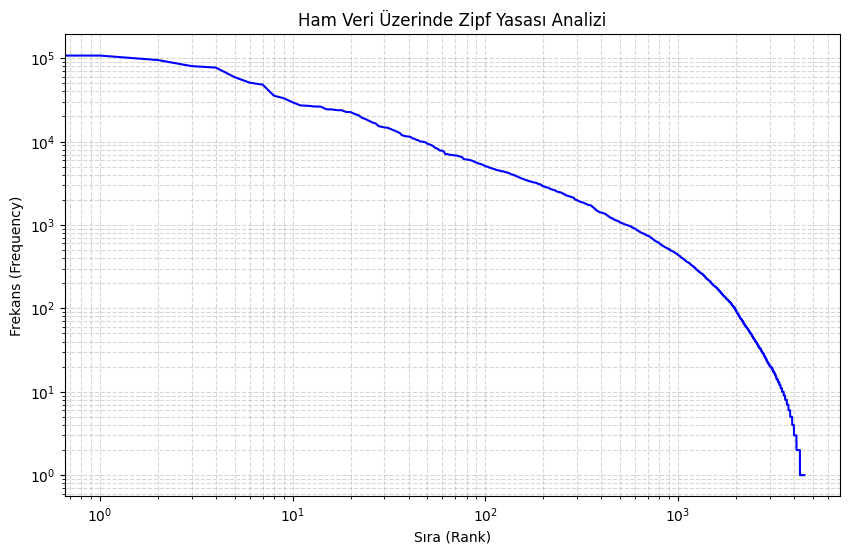

In [3]:
import matplotlib.pyplot as plt
from collections import Counter
import re

# Sadece Hasta_Sikayeti sütunundaki metinleri alıp tek bir dev metin haline getiriyoruz
tum_metin = " ".join(df['Hasta_Sikayeti'].astype(str))

# Basitçe kelimelere ayırma (Asıl tokenization işlemini ön işleme adımında yapacağız)
kelimeler = re.findall(r'\w+', tum_metin.lower())

# Kelime frekanslarını hesaplama ve büyükten küçüğe sıralama
frekanslar = Counter(kelimeler)
sirali_frekanslar = sorted(frekanslar.values(), reverse=True)

# Log-Log Grafiği Çizimi
plt.figure(figsize=(10, 6))
plt.plot(sirali_frekanslar, color='blue')
plt.yscale('log')
plt.xscale('log')
plt.title("Ham Veri Üzerinde Zipf Yasası Analizi")
plt.xlabel("Sıra (Rank)")
plt.ylabel("Frekans (Frequency)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

3.Ön İşleme (Pre-processing) Aşamaları
Veri setimizi modellemeye hazır, temiz bir hale getirmek için Python'un `re` (Regex) ve `nltk` kütüphanelerini kullanarak aşağıdaki adımları sırasıyla uyguladım:

1.Genel İçerik Temizliği ve Lowercasing: Regex kullanarak metindeki noktalama işaretlerini, sayıları ve gereksiz sembolleri temizledim. Sadece alfabemizdeki harfleri bırakarak tüm metni küçük harfe dönüştürdüm.
2.Tokenization: NLTK kütüphanesinin `word_tokenize` fonksiyonunu kullanarak metni kelime kelime (token) ayırdım.
3.Stop Word Removal: Türkçe diline özgü, sık kullanılan ama anlamsal değeri zayıf olan kelimeleri (ve, ile vb.) NLTK'nin Türkçe stop-words listesini kullanarak metinden çıkardım.
4.Stemming ve Lemmatization: NLTK kütüphanesindeki `SnowballStemmer` ve `WordNetLemmatizer` yapılarını kullanarak kelimeleri kök ve gövdelerine indirgedim.

*Not: Her işlem adımından sonra verinin nasıl değiştiğini göstermek amacıyla "Önce / Sonra" çıktıları kod bloğunun altında tablolar halinde raporlanmıştır.*

In [2]:
import pandas as pd
import re
import nltk
import subprocess
import sys
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# --- 0. VERİYİ HAFIZAYA ALMA (Hatayı çözen kısım) ---
df = pd.read_csv("ham_veri.csv")

# --- Türkçe Stemmer Kütüphanesini Kurma ve İçe Aktarma ---
try:
    from TurkishStemmer import TurkishStemmer
except ImportError:
    print("TurkishStemmer bulunamadı, indiriliyor...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "TurkishStemmer"])
    from TurkishStemmer import TurkishStemmer

# NLTK gerekli paketleri
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True) 
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Türkçe stop words listesi ve Stemmer tanımlama
stop_words = set(stopwords.words('turkish'))
stemmer = TurkishStemmer()

# --- 1. GENEL TEMİZLİK VE KÜÇÜK HARFE ÇEVİRME (LOWER-CASING) ---
df['temiz_metin'] = df['Hasta_Sikayeti'].apply(lambda x: re.sub(r'[^a-zçğıöşü\s]', '', str(x).lower()))

print("--- 1. Temizlik ve Lowercasing (Önce / Sonra) ---")
display(df[['Hasta_Sikayeti', 'temiz_metin']].head(3))


# --- 2. TOKENIZATION (KELİMELERE AYIRMA) ---
df['tokenized'] = df['temiz_metin'].apply(word_tokenize)

print("\n--- 2. Tokenization (Önce / Sonra) ---")
display(df[['temiz_metin', 'tokenized']].head(3))


# --- 3. STOP WORD REMOVAL (GEREKSİZ KELİMELERİ ATMA) ---
df['stop_words_removed'] = df['tokenized'].apply(lambda tokens: [w for w in tokens if not w in stop_words])

print("\n--- 3. Stop Word Removal (Önce / Sonra) ---")
display(df[['tokenized', 'stop_words_removed']].head(3))


# --- 4. STEMMING (TÜRKÇE KÖKE İNDİRGEME) ---
df['stemmed_metin'] = df['stop_words_removed'].apply(lambda tokens: " ".join([stemmer.stem(w) for w in tokens]))

print("\n--- 4. Stemming (Önce / Sonra) ---")
display(df[['stop_words_removed', 'stemmed_metin']].head(3))


# --- 5. LEMMATIZATION (SÖZLÜKSEL GÖVDEYE İNDİRGEME) ---
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
df['lemmatized_metin'] = df['stop_words_removed'].apply(lambda tokens: " ".join([lemmatizer.lemmatize(w) for w in tokens]))

print("\n--- 5. Lemmatization (Önce / Sonra) ---")
display(df[['stop_words_removed', 'lemmatized_metin']].head(3))

--- 1. Temizlik ve Lowercasing (Önce / Sonra) ---


,Hasta_Sikayeti,temiz_metin
0,İlacı kullanmaya başlayınca cildimde kaşıntılı...,ilacı kullanmaya başlayınca cildimde kaşıntılı...
1,İlacı kullanmaya başlayınca durumum daha da kö...,ilacı kullanmaya başlayınca durumum daha da kö...
2,"İğne yapılan yer kızardı ve tahriş oldu, dokun...",iğne yapılan yer kızardı ve tahriş oldu dokunu...



--- 2. Tokenization (Önce / Sonra) ---


,temiz_metin,tokenized
0,ilacı kullanmaya başlayınca cildimde kaşıntılı...,"[ilacı, kullanmaya, başlayınca, cildimde, kaşı..."
1,ilacı kullanmaya başlayınca durumum daha da kö...,"[ilacı, kullanmaya, başlayınca, durumum, daha,..."
2,iğne yapılan yer kızardı ve tahriş oldu dokunu...,"[iğne, yapılan, yer, kızardı, ve, tahriş, oldu..."



--- 3. Stop Word Removal (Önce / Sonra) ---


,tokenized,stop_words_removed
0,"[ilacı, kullanmaya, başlayınca, cildimde, kaşı...","[ilacı, kullanmaya, başlayınca, cildimde, kaşı..."
1,"[ilacı, kullanmaya, başlayınca, durumum, daha,...","[ilacı, kullanmaya, başlayınca, durumum, kötül..."
2,"[iğne, yapılan, yer, kızardı, ve, tahriş, oldu...","[iğne, yapılan, yer, kızardı, tahriş, oldu, do..."



--- 4. Stemming (Önce / Sonra) ---


,stop_words_removed,stemmed_metin
0,"[ilacı, kullanmaya, başlayınca, cildimde, kaşı...",ilaç kullanma başlay cilt kaşıntı kır dök çıkt
1,"[ilacı, kullanmaya, başlayınca, durumum, kötül...",ilaç kullanma başlay dur kötüleş dayanılmaz bi...
2,"[iğne, yapılan, yer, kızardı, tahriş, oldu, do...",iğn yapılan yer kızar tahriş olt dokun acıyor



--- 5. Lemmatization (Önce / Sonra) ---


,stop_words_removed,lemmatized_metin
0,"[ilacı, kullanmaya, başlayınca, cildimde, kaşı...",ilacı kullanmaya başlayınca cildimde kaşıntılı...
1,"[ilacı, kullanmaya, başlayınca, durumum, kötül...",ilacı kullanmaya başlayınca durumum kötüleşti ...
2,"[iğne, yapılan, yer, kızardı, tahriş, oldu, do...",iğne yapılan yer kızardı tahriş oldu dokununca...


4.Beklenen Çıktılar ve Dışa Aktarma
Ödev teslim yönergesine uygun olarak, veri temizleme ve gövde/kök bulma işlemleri tamamlandıktan sonra oluşturulan **Stemmed** ve **Lemmatized** verileri ayrı ayrı CSV dosyaları olarak dışa aktarılmıştır.

In [3]:
# Stemmed veri setini kaydetme
df[['Ilac_Adi', 'stemmed_metin']].to_csv('stemmed_veri.csv', index=False)

# Lemmatized veri setini kaydetme
df[['Ilac_Adi', 'lemmatized_metin']].to_csv('lemmatized_veri.csv', index=False)

print("İşlem tamam! 'stemmed_veri.csv' ve 'lemmatized_veri.csv' başarıyla oluşturuldu.")

İşlem tamam! 'stemmed_veri.csv' ve 'lemmatized_veri.csv' başarıyla oluşturuldu.
